In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import MonthLocator, DateFormatter, YearLocator

from tensorflow.keras.models import Sequential
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.layers import Dense, InputLayer, LSTM, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model
import keras

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

2026-01-19 10:19:12.725563: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768817952.941278      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768817953.013074      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768817953.544655      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768817953.544701      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768817953.544704      23 computation_placer.cc:177] computation placer alr

/kaggle/input/web-traffic-time-series-forecasting/sample_submission_2.csv.zip
/kaggle/input/web-traffic-time-series-forecasting/sample_submission_1.csv.zip
/kaggle/input/web-traffic-time-series-forecasting/train_2.csv.zip
/kaggle/input/web-traffic-time-series-forecasting/key_1.csv.zip
/kaggle/input/web-traffic-time-series-forecasting/key_2.csv.zip
/kaggle/input/web-traffic-time-series-forecasting/train_1.csv.zip


In [2]:
path1 = "/kaggle/input/web-traffic-time-series-forecasting/train_2.csv.zip"
path2 = "/kaggle/input/web-traffic-time-series-forecasting/key_1.csv.zip"
path3 = "/kaggle/input/web-traffic-time-series-forecasting/key_2.csv.zip"
path4 = "/kaggle/input/web-traffic-time-series-forecasting/train_1.csv.zip"

key1 = pd.read_csv(path2)
key2 = pd.read_csv(path3) 

train2 = pd.read_csv(path1)
train1= pd.read_csv(path4)

test = pd.read_csv('/kaggle/input/web-traffic-time-series-forecasting/sample_submission_1.csv.zip')

In [3]:
print(f"train2_shape: {train2.shape}")

train2_shape: (145063, 804)


In [4]:
train2.head(10)

,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,...,2017-09-01,2017-09-02,2017-09-03,2017-09-04,2017-09-05,2017-09-06,2017-09-07,2017-09-08,2017-09-09,2017-09-10
0,2NE1_zh.wikipedia.org_all-access_spider,18.0,11.0,5.0,13.0,14.0,9.0,9.0,22.0,26.0,...,19.0,33.0,33.0,18.0,16.0,27.0,29.0,23.0,54.0,38.0
1,2PM_zh.wikipedia.org_all-access_spider,11.0,14.0,15.0,18.0,11.0,13.0,22.0,11.0,10.0,...,32.0,30.0,11.0,19.0,54.0,25.0,26.0,23.0,13.0,81.0
2,3C_zh.wikipedia.org_all-access_spider,1.0,0.0,1.0,1.0,0.0,4.0,0.0,3.0,4.0,...,6.0,6.0,7.0,2.0,4.0,7.0,3.0,4.0,7.0,6.0
3,4minute_zh.wikipedia.org_all-access_spider,35.0,13.0,10.0,94.0,4.0,26.0,14.0,9.0,11.0,...,7.0,19.0,19.0,9.0,6.0,16.0,19.0,30.0,38.0,4.0
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_s...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,16.0,16.0,19.0,9.0,20.0,23.0,28.0,14.0,8.0,7.0
5,5566_zh.wikipedia.org_all-access_spider,12.0,7.0,4.0,5.0,20.0,8.0,5.0,17.0,24.0,...,13.0,13.0,45.0,4.0,13.0,20.0,18.0,17.0,14.0,11.0
6,91Days_zh.wikipedia.org_all-access_spider,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,12.0,8.0,5.0,7.0,8.0,10.0,8.0,5.0,3.0,5.0
7,A'N'D_zh.wikipedia.org_all-access_spider,118.0,26.0,30.0,24.0,29.0,127.0,53.0,37.0,20.0,...,74.0,39.0,11.0,55.0,71.0,44.0,25.0,39.0,25.0,50.0
8,AKB48_zh.wikipedia.org_all-access_spider,5.0,23.0,14.0,12.0,9.0,9.0,35.0,15.0,14.0,...,53.0,107.0,63.0,42.0,24.0,44.0,33.0,52.0,21.0,48.0
9,ASCII_zh.wikipedia.org_all-access_spider,6.0,3.0,5.0,12.0,6.0,5.0,4.0,13.0,9.0,...,20.0,16.0,22.0,19.0,21.0,32.0,34.0,29.0,23.0,25.0


In [5]:
WINDOW_SIZE = 80
horizon = 64

In [6]:
# --- Préparation des vecteurs temporels globaux ---
dates = pd.to_datetime(train2.columns[1:])
dow_global = (dates.dayofweek / 6)
month_global = (dates.month / 12)
we_global = (dates.dayofweek > 4).astype(int)

def create_dataset_correct(series, dow, m, we):
    X, y = [], []
    # On itère avec un pas de 10
    max_idx = len(series) - WINDOW_SIZE - horizon + 1
    for i in range(0, max_idx, 10):
        # 1. Fenêtre de trafic
        window_traffic = series[i : i + WINDOW_SIZE]
        
        # 2. Fenêtre des features temporelles (CORRECTION CRITIQUE ICI)
        # On prend les dates qui correspondent EXACTEMENT à cette fenêtre
        w_dow = dow[i : i + WINDOW_SIZE]
        w_m = m[i : i + WINDOW_SIZE]
        w_we = we[i : i + WINDOW_SIZE]
        
        # 3. Concaténation (Shape: 80, 4)
        # On met le trafic en (80, 1) et on colle les features
        sample = np.stack([window_traffic, w_dow, w_m, w_we], axis=1)
        
        # Target
        target = series[i + WINDOW_SIZE : i + WINDOW_SIZE + horizon]
        
        X.append(sample)
        y.append(target)
    return X, y

X_all, y_all = [], []
n_pages = min(10000, len(train2)) # Ajuste selon ta RAM (ex: 20000)

print(f"Traitement de {n_pages} pages...")
for i in range(n_pages):
    # Récupération série brute
    ts = pd.to_numeric(train2.iloc[i, 1:], errors='coerce').fillna(0)
    ts_log = np.log1p(ts.values)
    
    # Appel de la fonction corrigée
    X_p, y_p = create_dataset_correct(ts_log, dow_global, month_global, we_global)
    X_all.extend(X_p)
    y_all.extend(y_p)

train_input = np.array(X_all)
train_output = np.array(y_all)

print(f"Shape finale Input: {train_input.shape}") # Devrait être (N, 80, 4)

Traitement de 10000 pages...
Shape finale Input: (660000, 80, 4)


In [7]:
def train_neural_network(X, y, epochs=30, learning_rate=0.001):
    model = Sequential()
    
    model.add(InputLayer((WINDOW_SIZE, 4)))
    model.add(LSTM(128, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(64))
    model.add(Dropout(0.2))
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.1))
    model.add(Dense(horizon, activation='linear'))
    
    model.compile(
        loss='huber',  # Plus robuste aux outliers
        optimizer=Adam(learning_rate=learning_rate),
        metrics=[RootMeanSquaredError()]
    )
    
    # Early stopping
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    check_point = ModelCheckpoint('model.keras', save_best_only=True, monitor='val_loss')
    
    model.fit(X, y, epochs=epochs, validation_split=0.1, 
              callbacks=[check_point, early_stop], batch_size=64)
    return model


 
model = train_neural_network(train_input, train_output)


I0000 00:00:1768818044.551414      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1768818044.555266      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/30


I0000 00:00:1768818051.311368      67 cuda_dnn.cc:529] Loaded cuDNN version 91002


9282/9282 ━━━━━━━━━━━━━━━━━━━━ 93s 10ms/step - loss: 0.2755 - root_mean_squared_error: 0.8935 - val_loss: 0.1806 - val_root_mean_squared_error: 0.7792
Epoch 2/30
9282/9282 ━━━━━━━━━━━━━━━━━━━━ 89s 10ms/step - loss: 0.1857 - root_mean_squared_error: 0.7139 - val_loss: 0.1762 - val_root_mean_squared_error: 0.7803
Epoch 3/30
9282/9282 ━━━━━━━━━━━━━━━━━━━━ 89s 10ms/step - loss: 0.1812 - root_mean_squared_error: 0.7077 - val_loss: 0.1717 - val_root_mean_squared_error: 0.7662
Epoch 4/30
9282/9282 ━━━━━━━━━━━━━━━━━━━━ 89s 10ms/step - loss: 0.1782 - root_mean_squared_error: 0.7021 - val_loss: 0.1829 - val_root_mean_squared_error: 0.7907
Epoch 5/30
9282/9282 ━━━━━━━━━━━━━━━━━━━━ 89s 10ms/step - loss: 0.1754 - root_mean_squared_error: 0.6947 - val_loss: 0.1675 - val_root_mean_squared_error: 0.7620
Epoch 6/30
9282/9282 ━━━━━━━━━━━━━━━━━━━━ 89s 10ms/step - loss: 0.1737 - root_mean_squared_error: 0.6942 - val_loss: 0.1662 - val_root_mean_squared_error: 0.7588
Epoch 7/30
9282/9282 ━━━━━━━━━━━━━━━━━━

In [8]:
model = keras.models.load_model('model.keras')

In [9]:
x_raw = train2.iloc[:, -WINDOW_SIZE:].fillna(0).values
x_log = np.log1p(x_raw)

# CORRECTION ICI : On utilise dow_global, month_global, we_global
dow_pred = np.tile(dow_global[-WINDOW_SIZE:], (x_log.shape[0], 1))
month_pred = np.tile(month_global[-WINDOW_SIZE:], (x_log.shape[0], 1))
we_pred = np.tile(we_global[-WINDOW_SIZE:], (x_log.shape[0], 1))

x_final = np.stack([x_log, dow_pred, month_pred, we_pred], axis=2)

preds_log = model.predict(x_final, batch_size=512)

predictions = np.expm1(preds_log) 
predictions = np.clip(predictions, 0, None)

last_date = pd.to_datetime(train2.columns[-1])
dates_futures = pd.date_range(last_date + pd.Timedelta(days=1), periods=horizon)
pages = train2['Page'].values

res = []
# --- Vectorisation de la soumission (Beaucoup plus rapide) ---
print("Création du fichier de soumission...")
# Création des IDs de pages (Page_Date)
date_cols = [date.strftime('%Y-%m-%d') for date in dates_futures]
submission_df = pd.DataFrame(predictions, columns=date_cols)
submission_df['Page'] = pages

# Transformation de matrice large à format long (melt)
submission_df = submission_df.melt(id_vars='Page', var_name='Date', value_name='Visits')
submission_df['Page'] = submission_df['Page'] + '_' + submission_df['Date']
submission_df = submission_df.drop('Date', axis=1)

# Le reste de ton code pour le merge reste identique après ça

backup_median = train2.iloc[:, -49:].median(axis=1).fillna(0)
final_submission = key2.merge(submission_df, on='Page', how='left')

medians_mapped = final_submission['Page'].str.rsplit('_', n=1).str[0].map(
    pd.Series(backup_median.values, index=train2['Page'])
)
final_submission['Visits'] = final_submission['Visits'].fillna(medians_mapped).fillna(0)

final_submission[['Id', 'Visits']].to_csv('submission_lstm.csv', index=False)

284/284 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
Création du fichier de soumission...


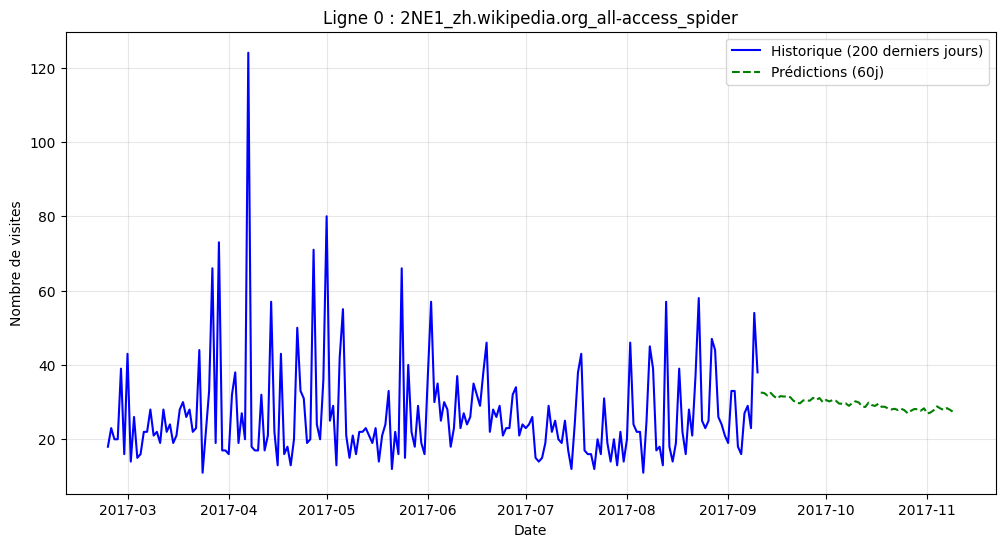

In [10]:
u = 0  # Indice de l'article (ligne u)
jours_a_afficher = 60  # Nombre de jours de prédiction (max 60)

ts = pd.to_numeric(train2.iloc[u, 1:], errors='coerce').fillna(0)

# On applique la transformation log sur la séquence d'entrée avant la prédiction
# On applique la transformation log sur la séquence d'entrée avant la prédiction
ts_log = np.log1p(ts.values[-WINDOW_SIZE:])

# CORRECTION ICI : Utilisation des variables globales
dow_g = dow_global[-WINDOW_SIZE:]
month_g = month_global[-WINDOW_SIZE:]
we_g = we_global[-WINDOW_SIZE:]

input_seq = np.stack([ts_log, dow_g, month_g, we_g], axis=1).reshape((1, WINDOW_SIZE, 4))
 
# On effectue la prédiction puis on inverse la transformation log avec expm1
prediction_log = model.predict(input_seq, verbose=0)[0]
prediction = np.expm1(prediction_log).clip(0.0)

last_date = pd.to_datetime(train2.columns[-1])
dates_hist = pd.to_datetime(train2.columns[1:])
dates_futures = pd.date_range(last_date + pd.Timedelta(days=1), periods=jours_a_afficher)

plt.figure(figsize=(12, 6))
plt.plot(dates_hist[-200:], ts[-200:], label="Historique (200 derniers jours)", color="blue")
plt.plot(dates_futures, prediction[:jours_a_afficher], label=f"Prédictions ({jours_a_afficher}j)", color="green", linestyle="--")
plt.title(f"Ligne {u} : {train2.iloc[u, 0]}")
plt.xlabel("Date")
plt.ylabel("Nombre de visites")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()